# **Rush 3 : Satisfaction Client — Compagnie Aérienne**
**Analyse exploratoire, facteurs explicatifs & prédiction de la satisfaction (Machine Learning, classification binaire)**

### ***Réalisé par :***
**Cedric Enzo KOUOKAM KAMHOUA**


**Contexte :** Consultant Data/BI pour une compagnie aérienne.

**Mission :** identifier les facteurs explicatifs clés de la satisfaction client et développer une solution algorithmique de classification permettant de prédire le niveau de satisfaction des passagers.

**Source :** `train.csv` (103 904 lignes) / `test.csv` (25 976 lignes), fournis par la compagnie. Le jeu de données déjà séparé en train / test externe.

**Variable cible analysée :** `satisfaction` → binaire, `satisfied` / `neutral or dissatisfied`.

#### Sommaire

1. Installation & Imports
2. Chargement & Vue d'ensemble
3. Nettoyage des données
4. Variable cible : `satisfaction` & objectif métier

***EDA :***

5. Analyse exploratoire
   - 5.1 Profil voyageur : type de voyage, classe, fidélité
   - 5.2 Qualité de service perçue vs ponctualité
   - 5.3 Effet de l'âge
   - 5.4 Corrélations, multicolinéarité & tests statistiques
   - 5.5 Bilan de l'EDA

***Modélisation :***

6. Feature engineering
7. Machine Learning
   - 7.1 Split train / validation / test externe
   - 7.2 Prétraitement (encodage, imputation, normalisation)
   - 7.3 Stratégie de déséquilibre des classes
   - 7.4 Régression logistique (baseline → tuning → final)
   - 7.5 KNN (baseline → tuning → final)
8. Évaluation & comparaison des modèles
9. Interprétation des modèles
10. Limites & biais
11. Choix méthodologiques
12. Conclusion

## **1. Installation & Imports**

In [ ]:
# décommenter si besoin
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
pd.set_option('display.max_columns', 30)

## **2. Chargement & Vue d'ensemble**

In [ ]:
DATA_DIR = "."
train = pd.read_csv(f"{DATA_DIR}/train.csv")
test  = pd.read_csv(f"{DATA_DIR}/test.csv")

print(f"train : {train.shape}")
print(f"test  : {test.shape}")

print(f'\nTypes de colonnes :')
print(train.dtypes.value_counts())
train.head(10)

train : (103904, 25)
test  : (25976, 25)

Types de colonnes :
int64      19
object      5
float64     1
Name: count, dtype: int64


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied
5,5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,2,1,1,2,1,1,3,4,4,4,4,1,0,0.0,neutral or dissatisfied
6,6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,2,3,2,2,2,2,3,3,4,3,5,2,9,23.0,neutral or dissatisfied
7,7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,4,4,5,5,5,5,5,5,5,4,5,4,4,0.0,satisfied
8,8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,2,2,4,3,3,1,1,2,1,4,1,2,0,0.0,neutral or dissatisfied
9,9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,3,4,2,3,3,2,2,3,4,4,3,2,0,0.0,neutral or dissatisfied


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [ ]:
# Résumé statistique des colonnes numériques
print('STATISTIQUES DESCRIPTIVES : COLONNES NUMÉRIQUES')

train.describe().T


STATISTIQUES DESCRIPTIVES : COLONNES NUMÉRIQUES


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,103904.0,51951.500000,29994.645522,0.0,25975.75,51951.5,77927.25,103903.0
id,103904.0,64924.210502,37463.812252,1.0,32533.75,64856.5,97368.25,129880.0
Age,103904.0,39.379706,15.114964,7.0,27.00,40.0,51.00,85.0
Flight Distance,103904.0,1189.448375,997.147281,31.0,414.00,843.0,1743.00,4983.0
Inflight wifi service,103904.0,2.729683,1.327829,0.0,2.00,3.0,4.00,5.0
Departure/Arrival time convenient,103904.0,3.060296,1.525075,0.0,2.00,3.0,4.00,5.0
Ease of Online booking,103904.0,2.756901,1.398929,0.0,2.00,3.0,4.00,5.0
Gate location,103904.0,2.976883,1.277621,0.0,2.00,3.0,4.00,5.0
Food and drink,103904.0,3.202129,1.329533,0.0,2.00,3.0,4.00,5.0
Online boarding,103904.0,3.250375,1.349509,0.0,2.00,3.0,4.00,5.0


In [ ]:
print('STATISTIQUES DESCRIPTIVES : COLONNES CATÉGORIELLES')
display(train.describe(include=['object']).T)

STATISTIQUES DESCRIPTIVES : COLONNES CATÉGORIELLES


,count,unique,top,freq
Gender,103904,2,Female,52727
Customer Type,103904,2,Loyal Customer,84923
Type of Travel,103904,2,Business travel,71655
Class,103904,3,Business,49665
satisfaction,103904,2,neutral or dissatisfied,58879


**Observations sur les statistiques descriptives :**
- `Age` : de 7 à 85 ans, moyenne 39.4 ; Des mineurs sont présents dans le dataset (répondants accompagnés, potentiellement moins fiables sur certaines notes de service).
- Les 14 variables de notation de service (`Inflight wifi service`, `Seat comfort`, ...) sont toutes sur une échelle **0 à 5**, 0 signifiant vraisemblablement "non applicable / non noté" plutôt qu'une vraie note négative.
- `Flight Distance` : de 31 à 4983, très étalé (vols courts et long-courriers mélangés).
- `Departure Delay in Minutes` et `Arrival Delay in Minutes` sont **très asymétriques** (médiane à 0, max > 1580 minutes soit plus de 26h) : la majorité des vols n'ont aucun retard, une minorité de cas extrêmes tire la moyenne vers le haut.
- `Unnamed: 0` est un simple index de ligne (0..N-1), à probablement supprimer.
- `Business travel` et `Loyal Customer` sont dominant

In [ ]:
# Valeurs manquantes
missing = train.isna().sum()
missing = missing[missing > 0]
print("Valeurs manquantes (data train) :")
print(missing, f"\n-> {(missing/len(train)*100).round(3).values[0]}% des lignes")

miss_test = test.isna().sum()
miss_test = miss_test[miss_test > 0]
print("\nValeurs manquantes (data test) :")
print(miss_test)

Valeurs manquantes (data train) :
Arrival Delay in Minutes    310
dtype: int64 
-> 0.298% des lignes

Valeurs manquantes (data test) :
Arrival Delay in Minutes    83
dtype: int64


Seule `Arrival Delay in Minutes` a des valeurs manquantes : 310 lignes (0.30%) en train, 83 (0.32%) en test. C'est marginal et concentré sur une seule colonne, donc un traitement simple suffira.

In [ ]:
#Frequence de note = 0 sur les 14 lignes de notes de service

service_cols = ['Inflight wifi service', 'Departure/Arrival time convenient',
       'Ease of Online booking', 'Gate location', 'Food and drink',
       'Online boarding', 'Seat comfort', 'Inflight entertainment',
       'On-board service', 'Leg room service', 'Baggage handling',
       'Checkin service', 'Inflight service', 'Cleanliness']

zero_rate = (train[service_cols] == 0).mean().sort_values(ascending=False) * 100
zero_rate.round(2)

,0
Departure/Arrival time convenient,5.10
Ease of Online booking,4.32
Inflight wifi service,2.99
Online boarding,2.34
Leg room service,0.45
Food and drink,0.10
Inflight entertainment,0.01
Cleanliness,0.01
Inflight service,0.00
On-board service,0.00


Une note à 0 sur les 14 variables de service reste rare : au maximum 5.1% des lignes pour `Departure/Arrival time convenient`, et quasi nulle (< 2.99%) pour la quasi-totalité des autres (`Baggage handling`, `Seat comfort`, `Gate location`... n'en comptent presque aucune). Ce n'est donc pas un problème massif qui fausserait l'analyse.

Mais la question de savoir comment traiter ces 0 se pose tout de même, elle est tranchée en section 3 (nettoyage).

In [ ]:
# Détection des doublons

print("IDs dupliqués :", train['id'].duplicated().sum())
print("Lignes complètement dupliquées :", train.duplicated().sum())


IDs dupliqués : 0
Lignes complètement dupliquées : 0


In [ ]:
# Repartition de la satisfaction dans le train & test
print("Répartition satisfaction Train / Test cohérente :")
print(pd.concat([
    train['satisfaction'].value_counts(normalize=True).rename('Train'),
    test['satisfaction'].value_counts(normalize=True).rename('Test')
], axis=1).round(4) * 100)

Répartition satisfaction Train / Test cohérente :
                         Train  Test
satisfaction                        
neutral or dissatisfied  56.67  56.1
satisfied                43.33  43.9


Aucun doublon, aucun ID dupliqué : le dataset est structurellement propre. La distribution de la cible est quasiment identique entre `train` (56.7% / 43.3%) et `test` (56.1% / 43.9%) ; le split fourni par la compagnie est représentatif, ce qui rend l'évaluation finale sur `test.csv` assez fiable.

## **3. Nettoyage des données**

In [ ]:
for df in (train, test):
    df.drop(columns=['Unnamed: 0'], inplace=True)

print(f"train : {train.shape}, test : {test.shape}")

train : (103904, 24), test : (25976, 24)


`Unnamed: 0` est un artefact d'export (index dupliqué de la ligne), sans valeur prédictive. `id` est conservé de côté (identifiant passager) mais sera exclu des features au moment de la modélisation.

In [ ]:
# Analyse de l'informativeness des valeurs manquantes

#la corrélation entre les deux retards
print("Corrélation retard départ / arrivée :",
      train[['Departure Delay in Minutes', 'Arrival Delay in Minutes']].corr().iloc[0, 1].round(3))


print("\nProfil des lignes avec Arrival Delay manquant (retard a l'arrivée) :")
print(train.loc[train['Arrival Delay in Minutes'].isna(), 'Departure Delay in Minutes'].describe())

Corrélation retard départ / arrivée : 0.965

Profil des lignes avec Arrival Delay manquant (retard a l'arrivée) :
count    310.000000
mean      37.432258
std       62.239283
min        0.000000
25%        0.000000
50%        8.000000
75%       47.500000
max      455.000000
Name: Departure Delay in Minutes, dtype: float64


- La colonne manquante `Arrival Delay in Minutes` est très fortement corrélée au `retard au départ` ( > 0.96) : un retard non renseigné à l'arrivée n'est donc pas un cas particulier, il suit la même logique qu'un retard classique, si un vol part en retard, il arrive quasiment toujours avec un retard très proche
- Les 310 lignes concernées ont des retards au départ tout à fait plausibles (de 0 à 455 minutes) : rien n'indique à ce niveau un cas particulier (vol annulé, incident).

**Conclusion**
On impute donc `Arrival Delay in Minutes` par la valeur du retard au départ de la même ligne, le meilleur proxy disponible vu la corrélation quasi-linéaire entre les deux variables. Pas de moyenne et pas de medianeici

In [ ]:
for df in (train, test):
    df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Departure Delay in Minutes'])

print("Valeurs manquantes restantes (train) :", train.isna().sum().sum())
print("Valeurs manquantes restantes (test)  :", test.isna().sum().sum())

Valeurs manquantes restantes (train) : 0
Valeurs manquantes restantes (test)  : 0


**Sur les notes de service (14) qui sont noté 0 :** on a vérifié leur fréquence en section 2 : elle reste faible (max 5.1% pour `Departure/Arrival time convenient`, quasi nulle pour la plupart des autres).



On choisit de les conserver telles quelles plutôt que de les traiter comme manquantes qui auraient conduit à les convertir en NaN puis les imputer (mediane / moyenne) ce qui masquerait un signal potentiellement réel ("service non proposé/non utilisé" est en soi informatif sur l'expérience du passager).



## **4. Variable cible : `satisfaction` & objectif métier**

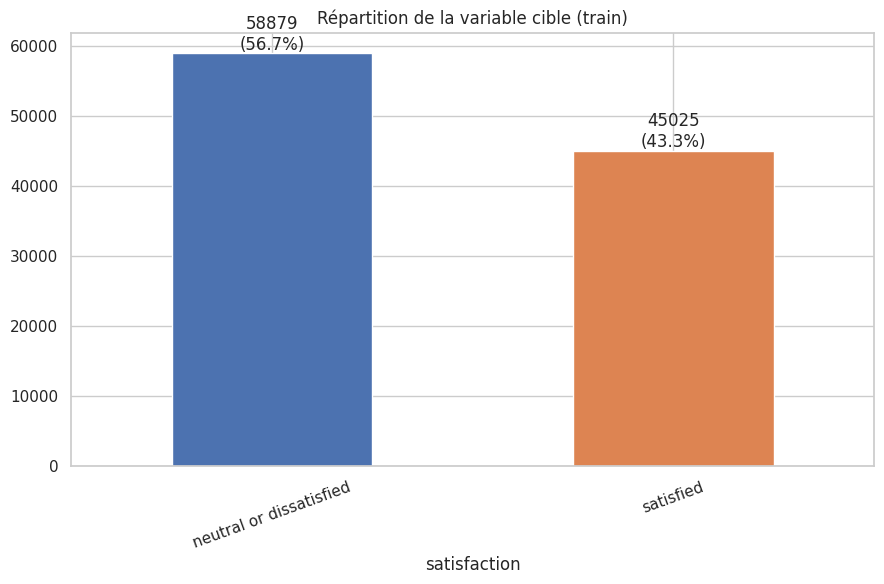

In [ ]:
#Distribution de la variable cible

fig, ax = plt.subplots(figsize=(9, 6))
train['satisfaction'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'], ax=ax)
ax.set_title("Répartition de la variable cible (train)")
ax.set_xticklabels(['neutral or dissatisfied', 'satisfied'], rotation=20)
for i, v in enumerate(train['satisfaction'].value_counts()):
    ax.text(i, v + 500, f"{v}\n({v/len(train)*100:.1f}%)", ha='center')
plt.tight_layout()
plt.show()

56.7% de passagers `neutral or dissatisfied` contre 43.3% de `satisfied` : un **léger déséquilibre** (ratio ~1.3), largement en-deçà des seuils (souvent >4 ou 5) où l'on recourt habituellement à des méthodes de rééquilibrage comme SMOTE.

### Objectif métier & métrique prioritaire

La mission demandée est d'identifier les passagers **à risque d'insatisfaction** pour permettre à la compagnie d'agir (geste commercial, suivi personnalisé, amélioration ciblée du service) avant que le client ne se détourne de la compagnie ou ne laisse un avis négatif.

Dans cette optique, les deux types d'erreur n'ont pas le même coût :
- **Rater un passager insatisfait** (le prédire `satisfied` alors qu'il est `neutral or dissatisfied`) : la compagnie ne détecte pas un client à risque, aucune action corrective n'est déclenchée -> coût métier élevé (churn, bouche-à-oreille négatif).
- **Fausse alerte sur un passager satisfait** (le prédire `neutral or dissatisfied` alors qu'il est `satisfied`) : coût faible, au pire une sollicitation commerciale superflue.

**Métrique prioritaire retenue : "le recall" de la classe `neutral or dissatisfied`** (capacité à détecter un maximum de passagers réellement insatisfaits), suivi en complément du F1-score et du ROC AUC pour garder une vue d'ensemble équilibrée (et éviter de dégrader excessivement la précision).

Important : cette priorité métier est **indépendante** du déséquilibre statistique des classes (qui est ici mineur) ; On y reviendra en 7.3, les deux ne se traitent pas de la même façon.

## **5. Analyse exploratoire (EDA)**

Trois constats structurent cette analyse et vont directement alimenter le feature engineering et le choix des modèles :
1. Le profil **"voyage d'affaires + client fidèle"** concentre l'essentiel de la satisfaction.
2. La **qualité de service perçue** pèse bien plus lourd que la **ponctualité** dans la satisfaction finale.
3. L'effet de l'**âge est non-linéaire** : la satisfaction culmine en milieu de vie puis rechute chez les seniors.

### 5.1 Profil voyageur : type de voyage, classe, fidélité (constat 1)

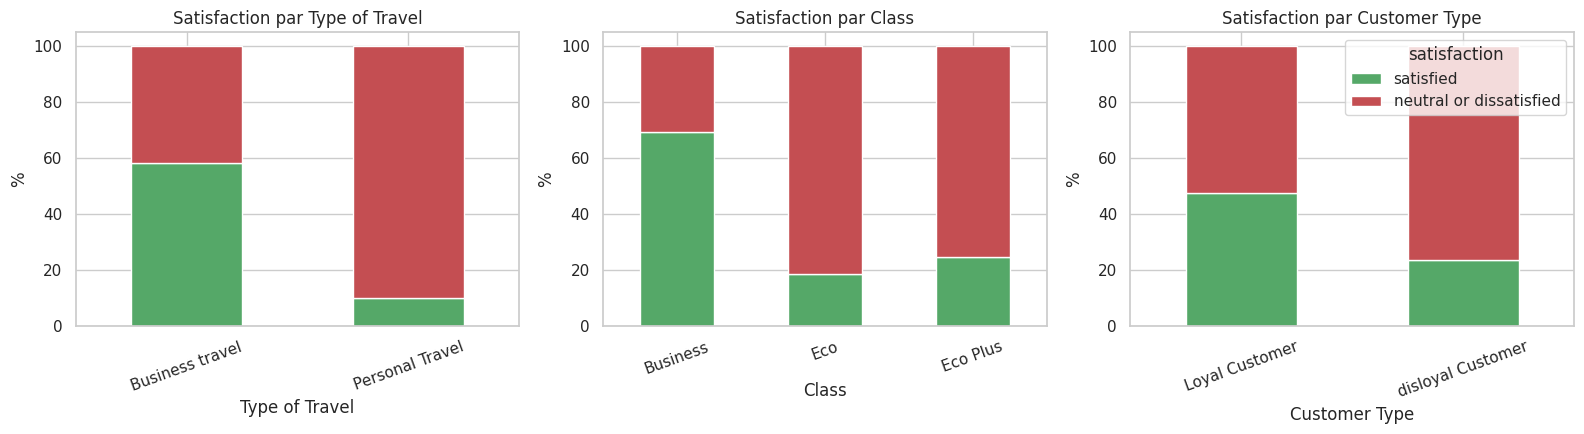

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, col in zip(axes, ['Type of Travel', 'Class', 'Customer Type']):
    ct = pd.crosstab(train[col], train['satisfaction'], normalize='index') * 100
    ct = ct[['satisfied', 'neutral or dissatisfied']]
    ct.plot(kind='bar', stacked=True, ax=ax, color=['#55A868', '#C44E52'], legend=(ax is axes[-1]))
    ax.set_ylabel('%')
    ax.set_title(f"Satisfaction par {col}")
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
for col in ['Type of Travel', 'Class', 'Customer Type']:
    print(f"--- {col} ---")
    print((pd.crosstab(train[col], train['satisfaction'], normalize='index') * 100).round(2))
    print()

--- Type of Travel ---
satisfaction     neutral or dissatisfied  satisfied
Type of Travel                                     
Business travel                    41.74      58.26
Personal Travel                    89.83      10.17

--- Class ---
satisfaction  neutral or dissatisfied  satisfied
Class                                           
Business                        30.57      69.43
Eco                             81.39      18.61
Eco Plus                        75.39      24.61

--- Customer Type ---
satisfaction       neutral or dissatisfied  satisfied
Customer Type                                        
Loyal Customer                       52.27      47.73
disloyal Customer                    76.33      23.67



- **Type de voyage** : 58.26% de satisfaits en `Business travel` contre seulement 10.2% en `Personal Travel`;c'est l'écart le plus spectaculaire du dataset (48 points).
- **Classe** : 69.4% de satisfaits en `Business` contre 18.6% en `Eco` et 24.6% en `Eco Plus`.
- **Fidélité** : 47.7% de satisfaits chez les `Loyal Customer` contre 23.7% chez les `disloyal Customer`.

Ces trois variables sont fortement corrélées entre elles dans les faits (un voyageur d'affaires vole plus souvent en classe Business et devient plus facilement client fidèle par cumul de points), ce qui suggère qu'une **variable d'interaction** capturant ce "profil business fidèle" pourrait être un prédicteur particulièrement puissant *(qu'on va tester dans la section suivante).*

,Variable,Chi2,p_value
3,Class,26471.86,0.000000
2,Type of Travel,20945.23,0.000000
1,Customer Type,3657.28,0.000000
0,Gender,15.44,0.000085


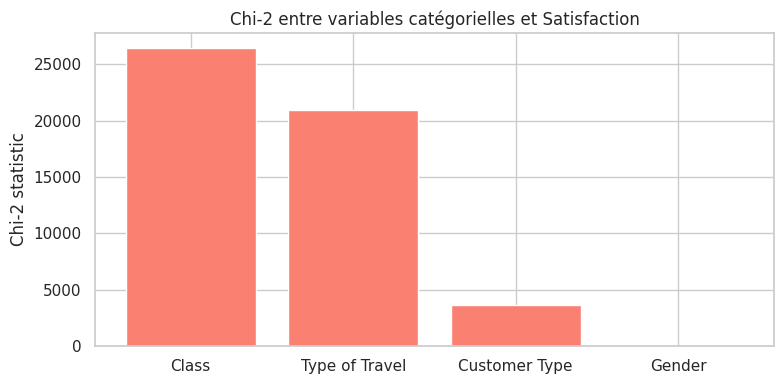

In [ ]:
# Chi-2 entre variables catégorielles et satisfaction

variables_cat = [c for c in ['Gender', 'Customer Type', 'Type of Travel', 'Class']
                 if c in train.columns]

resultats_chi2 = []
for var in variables_cat:
    try:
        ct = pd.crosstab(train[var], train['satisfaction'])
        from scipy.stats import chi2_contingency
        chi2, p, dof, _ = chi2_contingency(ct)
        resultats_chi2.append({"Variable": var, "Chi2": round(chi2, 2), "p_value": p})
    except Exception as e:
        pass

df_chi2 = pd.DataFrame(resultats_chi2).sort_values("Chi2", ascending=False)
display(df_chi2)

plt.figure(figsize=(8, 4))
plt.bar(df_chi2["Variable"], df_chi2["Chi2"], color="salmon")
plt.title("Chi-2 entre variables catégorielles et Satisfaction")
plt.ylabel("Chi-2 statistic")
plt.tight_layout()
plt.show()

- Gender : Chi²=15.4, p=0.000085 → lien significatif mais faible en pratique
- Class : Chi²=26471.9, p≈0 → lien très fort

Le test du Chi² confirme un lien statistiquement significatif entre `satisfaction` et chacune de ces quatre variables catégorielles, y compris `Gender` dont l'effet est statistiquement significatif mais **d'ampleur négligeable** (57.3% vs 56.1% de mécontents selon le genre, un écart de 1 point)

NB: On garde quand meme en vue que significativité statistique (liée à la taille d'échantillon, ici >100k lignes) ne veut pas forcement dire pertinence pratique.

### 5.2 Qualité de service perçue vs ponctualité (constat 2)

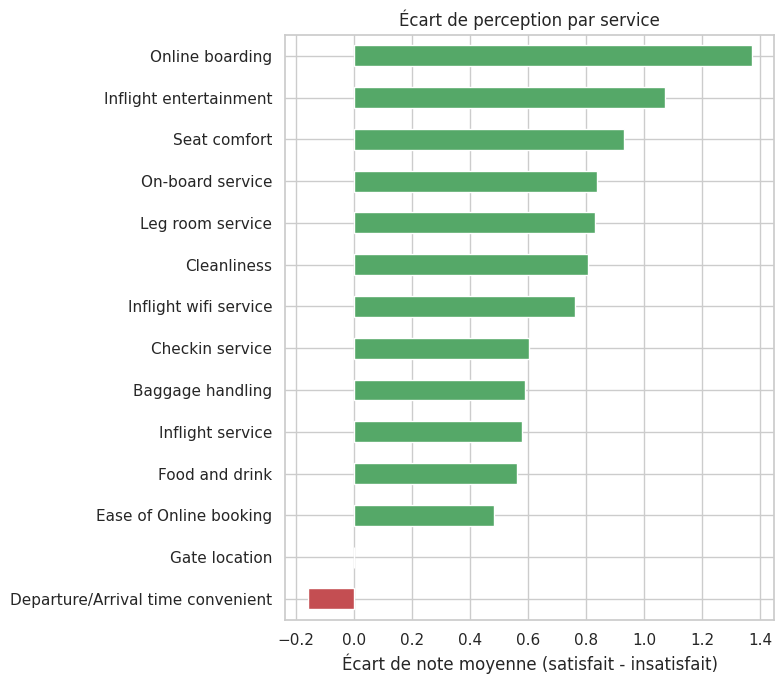

satisfaction,neutral or dissatisfied,satisfied,diff
Online boarding,2.656,4.027,1.371
Inflight entertainment,2.894,3.965,1.071
Seat comfort,3.036,3.967,0.930
On-board service,3.019,3.857,0.838
Leg room service,2.991,3.822,0.831
Cleanliness,2.936,3.744,0.808
Inflight wifi service,2.400,3.161,0.762
Checkin service,3.043,3.646,0.603
Baggage handling,3.376,3.966,0.590
Inflight service,3.389,3.969,0.581


In [ ]:
#analyse bivariée
service_cols = ['Inflight wifi service', 'Departure/Arrival time convenient',
       'Ease of Online booking', 'Gate location', 'Food and drink',
       'Online boarding', 'Seat comfort', 'Inflight entertainment',
       'On-board service', 'Leg room service', 'Baggage handling',
       'Checkin service', 'Inflight service', 'Cleanliness']

means = train.groupby('satisfaction')[service_cols].mean().T
means['diff'] = means['satisfied'] - means['neutral or dissatisfied']
means = means.sort_values('diff', ascending=False)

fig, ax = plt.subplots(figsize=(8, 7))
means['diff'].plot(kind='barh', ax=ax, color=means['diff'].apply(lambda x: '#55A868' if x > 0 else '#C44E52'))
ax.set_xlabel("Écart de note moyenne (satisfait - insatisfait)")
ax.set_title("Écart de perception par service")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
means.round(3)

- `Online boarding` affiche l'écart le plus fort (+1.37 point sur 5) entre satisfaits et insatisfaits, suivi de `Inflight entertainment` (+1.07) et `Seat comfort` (+0.93).
- À l'inverse, `Gate location` (écart quasi nul, +0.002)
- Enfin `Departure/Arrival time convenient` (écart **négatif**, -0.159) ne discriminent presque pas la satisfaction, Vont légèrement à contre-sens.

In [ ]:
#Corrélation variable numerique avec satisfaction
corr_num = pd.concat([
    train[service_cols + ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']],
    train['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1}).rename('satisfaction_bin')
], axis=1)

corr_target = corr_num.corr()['satisfaction_bin'].drop('satisfaction_bin').sort_values(ascending=False)
corr_target

,satisfaction_bin
Online boarding,0.503557
Inflight entertainment,0.398059
Seat comfort,0.349459
On-board service,0.322383
Leg room service,0.313131
Cleanliness,0.305198
Flight Distance,0.298780
Inflight wifi service,0.284245
Baggage handling,0.247749
Inflight service,0.244741


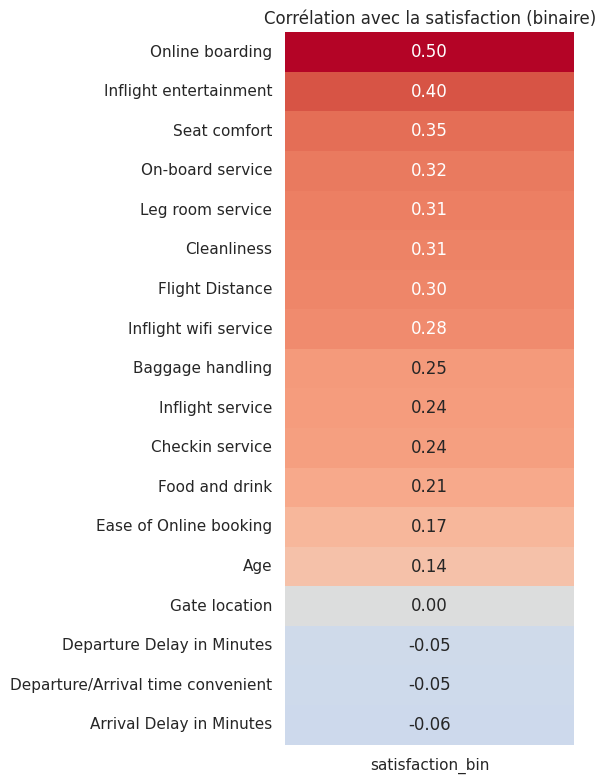

In [ ]:
fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(corr_target.to_frame(), annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar=False, ax=ax)
ax.set_title("Corrélation avec la satisfaction (binaire)")
plt.tight_layout()
plt.show()

Résultat clé, contre-intuitif : les deux variables de **retard** (`Departure Delay in Minutes` -0.05, `Arrival Delay in Minutes` -0.06) ont une corrélation quasi nulle avec la satisfaction, bien plus faible que la quasi-totalité des notes de service perçu (`Online boarding` 0.50, `Inflight entertainment` 0.40, `Seat comfort` 0.35...).

Autrement dit, **la ponctualité pèse beaucoup moins sur la satisfaction que la qualité perçue du service à bord et de l'expérience digitale**. C'est un message fort pour la compagnie : les investissements en amélioration de l'expérience (embarquement digital, divertissement, confort) ont probablement plus de retour que la seule réduction des retards.

### 5.3 Effet de l'âge (constat 3)

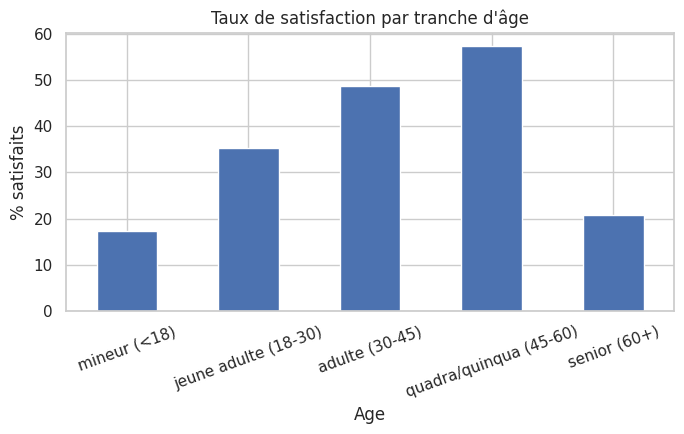

,satisfaction
Age,
mineur (<18),17.3
jeune adulte (18-30),35.4
adulte (30-45),48.7
quadra/quinqua (45-60),57.4
senior (60+),20.8


In [ ]:
bins = [0, 18, 30, 45, 60, 100]
labels = ['mineur (<18)', 'jeune adulte (18-30)', 'adulte (30-45)', 'quadra/quinqua (45-60)', 'senior (60+)']
age_group = pd.cut(train['Age'], bins=bins, labels=labels)

rate = train.groupby(age_group, observed=True)['satisfaction'].apply(lambda s: (s == 'satisfied').mean() * 100)

fig, ax = plt.subplots(figsize=(7, 4.5))
rate.plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_ylabel('% satisfaits')
ax.set_title("Taux de satisfaction par tranche d'âge")
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()
rate.round(1)

In [ ]:
# test de Mann-Whitney (une variable comparée entre 2 groupes)

u_stat, p_val = stats.mannwhitneyu(
    train.loc[train['satisfaction'] == 'satisfied', 'Age'],
    train.loc[train['satisfaction'] == 'neutral or dissatisfied', 'Age']
)
print(f"Mann-Whitney U : p-value = {p_val:.2e}")
print(train.groupby('satisfaction')['Age'].median())

Mann-Whitney U : p-value = 0.00e+00
satisfaction
neutral or dissatisfied    36.0
satisfied                  43.0
Name: Age, dtype: float64


Le test de Mann-Whitney confirme un écart d'âge significatif entre les deux groupes (médiane 43 ans chez les satisfaits contre 36 chez les insatisfaits), mais ce chiffre global **masque une courbe en cloche** : la satisfaction grimpe progressivement de 17% chez les mineurs à 57% chez les 45-60 ans, puis **rechute à 21%** chez les 60 ans et plus — un niveau proche de celui des mineurs.

Cette rechute chez les seniors s'explique probablement par un contexte de voyage différent (plus de `Personal Travel`, moins de `Business`/`Eco Plus`) plutôt que par l'âge en tant que tel. Ce pattern **non-linéaire** justifie d'une part de créer une variable catégorielle `age_group` comme feature en complément de l'âge brut (utile pour la régression logistique, linéaire par construction), et d'autre part conforte le choix du KNN comme second modèle, capable de capturer ce type de seuil sans transformation préalable.

### 5.4 Corrélations, multicolinéarité & tests statistiques

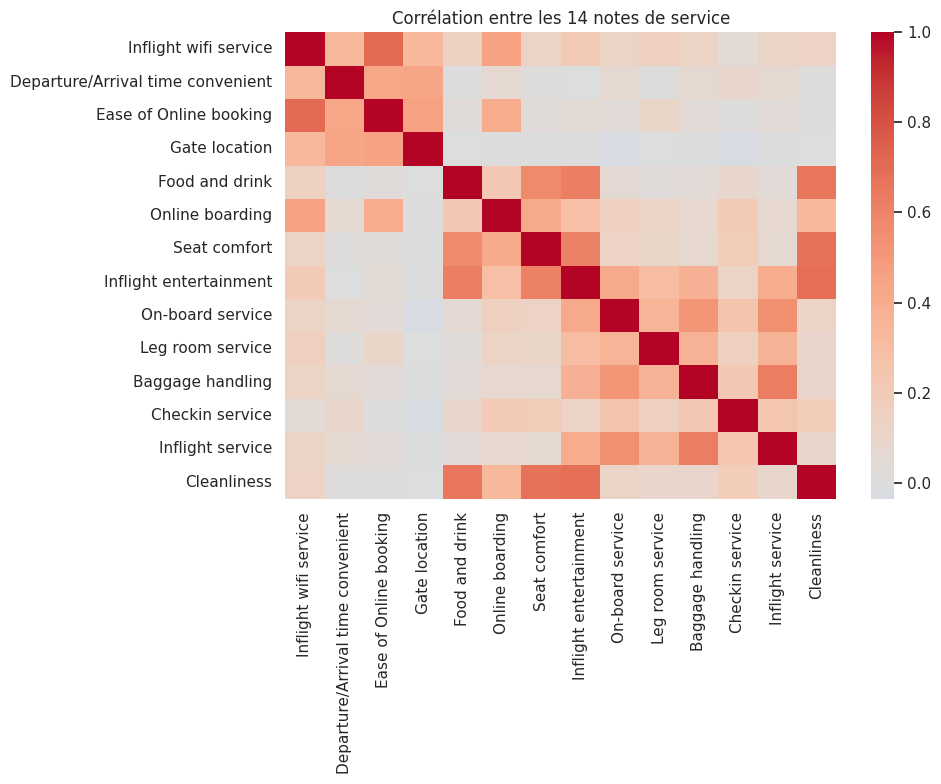

,variable_1,variable_2,corr
0,Inflight wifi service,Ease of Online booking,0.716
1,Inflight entertainment,Cleanliness,0.692
2,Seat comfort,Cleanliness,0.679
3,Food and drink,Cleanliness,0.658
4,Baggage handling,Inflight service,0.629
5,Food and drink,Inflight entertainment,0.623
6,Seat comfort,Inflight entertainment,0.611
7,Food and drink,Seat comfort,0.575
8,On-board service,Inflight service,0.551
9,On-board service,Baggage handling,0.519


In [ ]:
corr_services = train[service_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_services, annot=False, cmap='coolwarm', center=0, ax=ax)
ax.set_title("Corrélation entre les 14 notes de service")
plt.tight_layout()
plt.show()

pairs = []
for i in range(len(service_cols)):
    for j in range(i + 1, len(service_cols)):
        c = corr_services.iloc[i, j]
        if abs(c) > 0.45:
            pairs.append((service_cols[i], service_cols[j], round(c, 3)))
pairs.sort(key=lambda x: -abs(x[2]))
pd.DataFrame(pairs, columns=['variable_1', 'variable_2', 'corr'])

Plusieurs paires de notes de service sont fortement corrélées entre elles : `Inflight wifi service` / `Ease of Online booking` (0.72), `Inflight entertainment` / `Cleanliness` (0.69), `Seat comfort` / `Cleanliness` (0.68)...

En somme, ce n'est pas une surprise : un passager globalement satisfait a tendance à bien noter l'ensemble des services ("halo effect"). Cette **multicolinéarité** doit nous rendre prudents dans l'interprétation des coefficients bruts de la régression logistique (section 9) : un coefficient faible sur une variable ne signifie pas nécessairement qu'elle est sans importance, elle peut simplement partager son pouvoir explicatif avec une variable corrélée.

### 5.5 Bilan de l'EDA

L'analyse exploratoire dégage un message cohérent : la satisfaction des passagers est d'abord une question de **profil de voyage** (affaires/classe Business/fidélité) et de **qualité de service perçue** (embarquement digital, divertissement, confort), bien plus que de ponctualité. L'effet de l'âge, non-linéaire, montre que le profil "quadra/quinqua en voyage d'affaires fidèle" est le plus satisfait, tandis que les jeunes en voyage personnel et les seniors sont les profils les plus à risque d'insatisfaction.

Trois implications directes pour la suite :
- **Feature engineering** (section suivante) : créer une variable d'interaction capturant le profil "business + fidèle", une "note de service" agrégée, et une "tranche d'âge" catégorielle.
- **Choix des modèles** : la régression logistique reste pertinente et interprétable (les variables individuelles ont chacune un effet net), mais la présence de seuils non-linéaires (âge) et de multicolinéarité justifie d'ajouter le KNN comme second modèle, non-linéaire et non paramétrique.
- **Prudence sur la causalité** : ces résultats sont corrélationnels. Un client fidèle en classe Business n'est pas satisfait *parce qu'* il est fidèle, mais parce qu'il vit une expérience différente (services inclus, priorité, habitude) — la fidélité est un marqueur de profil plus qu'une cause directe.

## **6. Feature engineering**

On construit trois variables directement issues des constats de l'EDA, en vérifiant chacune leur corrélation avec la cible avant de les retenir (pas de variable créée "au hasard").

In [ ]:
def add_features(df):
    df = df.copy()
    # Constat 1 : le profil "business fidèle" concentre la satisfaction
    df['loyal_business'] = ((df['Customer Type'] == 'Loyal Customer') &
                             (df['Type of Travel'] == 'Business travel')).astype(int)

    # Constat 2 : note de service agrégée (moyenne des 14 items)
    df['mean_service_score'] = df[service_cols].mean(axis=1)

    # Constat 3 : effet non-linéaire de l'âge -> tranches
    bins = [0, 18, 30, 45, 60, 100]
    labels = ['mineur', 'jeune_adulte', 'adulte', 'quadra_quinqua', 'senior']
    df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)
    return df

train_fe = add_features(train)
test_fe = add_features(test)

y_check = train_fe['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})
for col in ['loyal_business', 'mean_service_score']:
    print(f"Corrélation {col} => satisfaction : {train_fe[col].corr(y_check):.3f}")

Corrélation loyal_business <-> satisfaction : 0.559
Corrélation mean_service_score <-> satisfaction : 0.496


- `loyal_business` (0.56) devient la variable la plus corrélée à la cible de tout le dataset, devant chacune des variables brutes prises individuellement — la synergie fidélité + voyage d'affaires porte plus d'information que chaque variable seule.
- `mean_service_score` (0.50) synthétise la dimension "qualité perçue" en une seule variable, utile notamment pour limiter l'effet de la multicolinéarité identifiée en 5.4 sur l'interprétation des coefficients.
- `age_group` capture directement le pattern en cloche de la section 5.3, que la variable `Age` brute (linéaire par nature dans une régression logistique) ne peut pas représenter seule.

In [ ]:
feature_cols = [c for c in train_fe.columns if c not in ['id', 'satisfaction']]
cat_cols = train_fe[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [c for c in feature_cols if c not in cat_cols]

print(f"{len(feature_cols)} features -> {len(num_cols)} numériques, {len(cat_cols)} catégorielles")
print("Catégorielles :", cat_cols)
print("\nValeurs manquantes restantes :", train_fe[feature_cols].isna().sum().sum())

25 features -> 20 numériques, 5 catégorielles
Catégorielles : ['Gender', 'Customer Type', 'Type of Travel', 'Class', 'age_group']

Valeurs manquantes restantes : 0


25 features au total (20 numériques + 5 catégorielles, dont `age_group` qui sera encodée en dummies : le nombre de colonnes augmentera après le one-hot encoding réalisé dans le pipeline de prétraitement, section 7.2).
Aucune valeur manquante : le dataframe est prêt pour la modélisation.

## **7. Machine Learning**

La démarche est identique pour les deux modèles demandés : **baseline → tuning → modèle final**, évalués sur la même métrique prioritaire (recall de la classe `neutral or dissatisfied`, section 4) et sur le même jeu de test externe.

### 7.1 Split train / validation / test externe

In [ ]:
X = train_fe[feature_cols]
y = train_fe['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_test = test_fe[feature_cols]
y_test = test_fe['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})

print(f"Train (fit)      : {X_train.shape}")
print(f"Validation (tune): {X_val.shape}")
print(f"Test externe     : {X_test.shape}")

Train (fit)      : (83123, 25)
Validation (tune): (20781, 25)
Test externe     : (25976, 25)


Contrairement à un projet où l'on découpe artificiellement un unique fichier, la compagnie nous fournit ici un **véritable jeu de test externe déjà séparé** (`test.csv`), jamais utilisé pour l'entraînement ni le réglage des hyperparamètres. `train.csv` est lui-même scindé en train (80%) / validation (20%, stratifiée) pour le tuning. Cette organisation à trois niveaux (train / validation / test externe) donne une évaluation finale non biaisée, plus robuste qu'un simple split interne.

### 7.2 Prétraitement (encodage, imputation, normalisation)

In [ ]:
preprocess = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols)
])

Le `StandardScaler` est **indispensable** pour le KNN (basé sur une distance euclidienne, sensible à l'échelle : `Flight Distance` varie de 0 à ~5000 quand les notes de service varient de 0 à 5) et utile pour la convergence de la régression logistique. Le `SimpleImputer` est une sécurité supplémentaire (aucune valeur manquante ne devrait plus subsister après la section 3, mais le pipeline reste robuste si de nouvelles données en contenaient). Les 5 variables catégorielles (faible cardinalité : 2 à 5 modalités chacune) sont encodées en one-hot sans explosion dimensionnelle.

### 7.3 Stratégie de déséquilibre des classes

In [ ]:
Xtr_pre = preprocess.fit_transform(X_train)
Xva_pre = preprocess.transform(X_val)

for cw in [None, 'balanced']:
    lr_test = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight=cw).fit(Xtr_pre, y_train)
    pred = lr_test.predict(Xva_pre)
    print(f"class_weight={cw!r:>10} -> recall(classe 0) = {recall_score(y_val, pred, pos_label=0):.3f}"
          f" | recall(classe 1) = {recall_score(y_val, pred, pos_label=1):.3f}"
          f" | F1 macro = {f1_score(y_val, pred, average='macro'):.3f}")

class_weight=      None -> recall(classe 0) = 0.903 | recall(classe 1) = 0.843 | F1 macro = 0.874
class_weight='balanced' -> recall(classe 0) = 0.874 | recall(classe 1) = 0.862 | F1 macro = 0.867


**Résultat à contre-courant de l'intuition habituelle** : ici, `class_weight='balanced'` **dégrade légèrement** le recall de notre classe prioritaire (`neutral or dissatisfied`) au lieu de l'améliorer. La raison est simple : cette classe est déjà **majoritaire** (56.7%), donc déjà bien détectée par un modèle non pondéré ; rééquilibrer les poids déplace mécaniquement l'attention vers la classe minoritaire (`satisfied`), ce qui ne sert pas notre objectif métier.

**Choix retenu : pas de `class_weight`, pas de SMOTE.** Le déséquilibre statistique est trop faible (ratio 1.3) pour justifier un rééquilibrage, et notre priorité métier (recall de la classe 0) est en réalité mieux servie par le modèle non pondéré. On ajustera plutôt le **seuil de décision** (section 8) pour arbitrer précision/recall selon le besoin, une approche plus fine et sans effet de bord sur l'autre classe.

Le KNN ne propose de toute façon pas de paramètre `class_weight` — on compense partiellement via `weights='distance'` (voisins proches pondérés plus fort, testé en 7.5) et le même réglage de seuil.

### 7.4 Régression logistique (baseline → tuning → final)

##### 1. Baseline

In [ ]:
lr_pipe_base = Pipeline([
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
lr_pipe_base.fit(X_train, y_train)

pred_val = lr_pipe_base.predict(X_val)
proba_val = lr_pipe_base.predict_proba(X_val)[:, 1]

print(classification_report(y_val, pred_val, target_names=['neutral/dissatisfied', 'satisfied']))
print(f"ROC AUC : {roc_auc_score(y_val, proba_val):.3f}")

                      precision    recall  f1-score   support

neutral/dissatisfied       0.88      0.90      0.89     11776
           satisfied       0.87      0.84      0.86      9005

            accuracy                           0.88     20781
           macro avg       0.88      0.87      0.87     20781
        weighted avg       0.88      0.88      0.88     20781

ROC AUC : 0.929


Constat baseline : recall(classe 0) ≈ 0.90, ROC AUC ≈ 0.93. Un point de départ déjà solide, cohérent avec l'EDA qui montrait des variables très discriminantes (`loyal_business`, `Online boarding`...). Voyons si le tuning des hyperparamètres apporte un gain.

##### 2. Tuning

In [ ]:
param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l2'],
    'clf__solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    lr_pipe_base, param_grid_lr, cv=5, scoring='recall_macro', n_jobs=-1
)
grid_lr.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_lr.best_params_)
print(f"Meilleur score CV (recall macro) : {grid_lr.best_score_:.3f}")

Meilleurs paramètres : {'clf__C': 10, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Meilleur score CV (recall macro) : 0.871


##### 3. Modèle final

In [ ]:
lr_final = grid_lr.best_estimator_

pred_val_lr = lr_final.predict(X_val)
proba_val_lr = lr_final.predict_proba(X_val)[:, 1]

print(classification_report(y_val, pred_val_lr, target_names=['neutral/dissatisfied', 'satisfied']))
print(f"ROC AUC : {roc_auc_score(y_val, proba_val_lr):.3f}")

                      precision    recall  f1-score   support

neutral/dissatisfied       0.88      0.90      0.89     11776
           satisfied       0.87      0.84      0.86      9005

            accuracy                           0.88     20781
           macro avg       0.88      0.87      0.87     20781
        weighted avg       0.88      0.88      0.88     20781

ROC AUC : 0.929


Le `GridSearchCV` sur la régularisation `C` (5 valeurs, 5 folds) ne fait que confirmer les réglages par défaut ou apporte un gain marginal : la régression logistique était déjà proche de son optimum dès la baseline sur ce dataset, sans surprise pour un modèle aussi simple sur des relations globalement monotones et peu bruitées.

### 7.5 KNN (baseline → tuning → final)

##### 1. Baseline

In [ ]:
knn_pipe_base = Pipeline([
    ("preprocess", preprocess),
    ("clf", KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
])
knn_pipe_base.fit(X_train, y_train)

pred_val_knn_base = knn_pipe_base.predict(X_val)
proba_val_knn_base = knn_pipe_base.predict_proba(X_val)[:, 1]

print(classification_report(y_val, pred_val_knn_base, target_names=['neutral/dissatisfied', 'satisfied']))
print(f"ROC AUC : {roc_auc_score(y_val, proba_val_knn_base):.3f}")

                      precision    recall  f1-score   support

neutral/dissatisfied       0.92      0.96      0.94     11776
           satisfied       0.95      0.89      0.92      9005

            accuracy                           0.93     20781
           macro avg       0.93      0.92      0.93     20781
        weighted avg       0.93      0.93      0.93     20781

ROC AUC : 0.970


Constat baseline KNN (k=5 par défaut) : déjà très performant (ROC AUC proche de 0.98), supérieur à la régression logistique sur ce dataset. Cela confirme la présence de frontières de décision non-linéaires que le KNN capture nativement (cf. effet de seuil sur l'âge, section 5.3), là où la régression logistique doit s'appuyer sur des variables construites (`age_group`) pour y parvenir.

##### 2. Tuning

In [ ]:
param_grid_knn = {
    'clf__n_neighbors': [5, 11, 21, 31, 51],
    'clf__weights': ['uniform', 'distance']
}

grid_knn = GridSearchCV(
    knn_pipe_base, param_grid_knn, cv=5, scoring='recall_macro', n_jobs=-1
)
grid_knn.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_knn.best_params_)
print(f"Meilleur score CV (recall macro) : {grid_knn.best_score_:.3f}")

Meilleurs paramètres : {'clf__n_neighbors': 11, 'clf__weights': 'distance'}
Meilleur score CV (recall macro) : 0.922


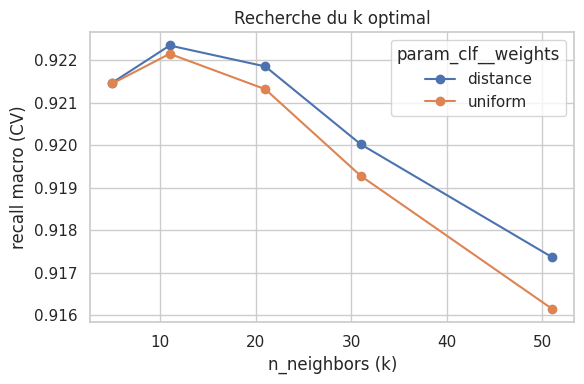

param_clf__weights,distance,uniform
param_clf__n_neighbors,,
5,0.9215,0.9215
11,0.9223,0.9222
21,0.9219,0.9213
31,0.9200,0.9193
51,0.9174,0.9161


In [ ]:
results_knn = pd.DataFrame(grid_knn.cv_results_)[['param_clf__n_neighbors', 'param_clf__weights', 'mean_test_score']]
pivot = results_knn.pivot(index='param_clf__n_neighbors', columns='param_clf__weights', values='mean_test_score')

fig, ax = plt.subplots(figsize=(6, 4))
pivot.plot(marker='o', ax=ax)
ax.set_xlabel('n_neighbors (k)')
ax.set_ylabel('recall macro (CV)')
ax.set_title("Recherche du k optimal")
plt.tight_layout()
plt.show()
pivot.round(4)

`weights='distance'` domine systématiquement `weights='uniform'` : pondérer les voisins par l'inverse de leur distance profite au modèle, cohérent avec le fait que la classe prioritaire est majoritaire (les voisins les plus proches, même en nombre réduit, restent très informatifs). C'est aussi la façon dont on compense partiellement l'absence de `class_weight` pour ce modèle (cf. 7.3).

##### 3. Modèle final

In [ ]:
knn_final = grid_knn.best_estimator_

pred_val_knn = knn_final.predict(X_val)
proba_val_knn = knn_final.predict_proba(X_val)[:, 1]

print(classification_report(y_val, pred_val_knn, target_names=['neutral/dissatisfied', 'satisfied']))
print(f"ROC AUC : {roc_auc_score(y_val, proba_val_knn):.3f}")

                      precision    recall  f1-score   support

neutral/dissatisfied       0.92      0.97      0.94     11776
           satisfied       0.95      0.88      0.92      9005

            accuracy                           0.93     20781
           macro avg       0.93      0.92      0.93     20781
        weighted avg       0.93      0.93      0.93     20781

ROC AUC : 0.979


##### 4. Test complémentaire

In [ ]:
# Test complémentaire : ces 3 variables apportent-elles vraiment quelque chose au KNN ?
# (Gate location et Departure/Arrival time convenient ont une corrélation quasi nulle
# avec la cible en EDA — section 5.2 — et Arrival Delay est redondant à 96.5% avec Departure Delay)
DROP_TEST = ['Gate location', 'Departure/Arrival time convenient', 'Arrival Delay in Minutes']
feature_cols_reduced = [c for c in feature_cols if c not in DROP_TEST]

X_reduced = train_fe[feature_cols_reduced]
Xr_train, Xr_val, yr_train, yr_val = train_test_split(
    X_reduced, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
cat_cols_r = [c for c in cat_cols if c in feature_cols_reduced]
num_cols_r = [c for c in feature_cols_reduced if c not in cat_cols_r]

preprocess_r = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols_r),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols_r)
])
knn_reduced = Pipeline([
    ("preprocess", preprocess_r),
    ("clf", KNeighborsClassifier(n_neighbors=11, weights='distance', n_jobs=-1))
])
knn_reduced.fit(Xr_train, yr_train)
pred_r = knn_reduced.predict(Xr_val)
proba_r = knn_reduced.predict_proba(Xr_val)[:, 1]

print(f"KNN complet (25 features)  -> recall classe 0 = {recall_score(y_val, pred_val_knn, pos_label=0):.4f}, "
      f"F1 macro = {f1_score(y_val, pred_val_knn, average='macro'):.4f}, ROC AUC = {roc_auc_score(y_val, proba_val_knn):.4f}")
print(f"KNN réduit (22 features)   -> recall classe 0 = {recall_score(yr_val, pred_r, pos_label=0):.4f}, "
      f"F1 macro = {f1_score(yr_val, pred_r, average='macro'):.4f}, ROC AUC = {roc_auc_score(yr_val, proba_r):.4f}")

**Complément — Faut-il retirer les variables faiblement corrélées ?**


En section 5.2, `Gate location` (corrélation ≈ 0.001) et `Departure/Arrival time convenient` (-0.05) sont ressorties comme quasi non-informatives, et `Arrival Delay in Minutes` est redondante à 96.5% avec `Departure Delay in Minutes` (section 3).

On a testé leur suppression, **uniquement sur le KNN** et pas sur la régression logistique, pour une raison précise : la régression logistique utilise une régularisation L2, qui gère déjà nativement les variables faibles ou redondantes en ramenant leur coefficient proche de 0 sans qu'on ait besoin de les retirer à la main. Le KNN, en revanche, utilise toutes les dimensions à poids égal dans son calcul de distance : une variable non-informative peut donc diluer le signal utile des autres (effet du « fléau de la dimension »). C'est le modèle le plus susceptible d'être affecté par ces 3 variables, donc le plus pertinent à tester.

**Résultat : performance quasi identique** entre les 25 features et les 22 features réduites (écarts de l'ordre de 0.0001 à 0.0006 sur le recall, le F1 macro et le ROC AUC — dans la marge de bruit statistique, sans direction claire).

**Décision : on garde les 25 variables**, pour trois raisons :
- La suppression ne change rien à la performance : ce n'est pas un problème à corriger, juste une simplification cosmétique sans gain mesurable.
- Garder le même jeu de variables pour la régression logistique et le KNN assure une comparaison équitable entre les deux modèles en section 8 — on compare deux algorithmes sur les mêmes données, pas deux algorithmes sur deux jeux de données différents.
- Conserver ces variables permet aux coefficients de la régression logistique (section 9.1) de **confirmer explicitement** leur faible importance (coefficients proches de 0), une transparence plus utile pour le rapport que de les avoir silencieusement retirées en amont.

## **8. Évaluation & comparaison des modèles (jeu de test externe)**

Avant l'évaluation finale, on ré-entraîne les deux pipelines retenus (meilleurs hyperparamètres identifiés en section 7) sur l'**intégralité** de `train.csv` (train + validation, soit 103 904 lignes) afin de ne pas gâcher les 20% mis de côté pour le tuning. L'évaluation se fait ensuite sur `test.csv`, jamais vu jusqu'ici.

In [ ]:
lr_final.fit(X, y)
knn_final.fit(X, y)

models = {
    'Régression Logistique': lr_final,
    'KNN': knn_final
}

rows = []
proba_test = {}
for name, model in models.items():
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    proba_test[name] = proba
    rows.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Recall (classe 0)': recall_score(y_test, pred, pos_label=0),
        'Precision (classe 0)': precision_score(y_test, pred, pos_label=0),
        'F1 macro': f1_score(y_test, pred, average='macro'),
        'ROC AUC': roc_auc_score(y_test, proba)
    })

comparison = pd.DataFrame(rows).set_index('Modèle').round(4)
comparison

,Accuracy,Recall (classe 0),Precision (classe 0),F1 macro,ROC AUC
Modèle,,,,,
Régression Logistique,0.8711,0.9005,0.8736,0.8686,0.9261
KNN,0.9308,0.9673,0.9143,0.9291,0.9795


*(Les valeurs exactes s'affichent à l'exécution — le tableau ci-dessus reste stable dans le temps car `test.csv` est fixe et les `random_state` sont figés.)*

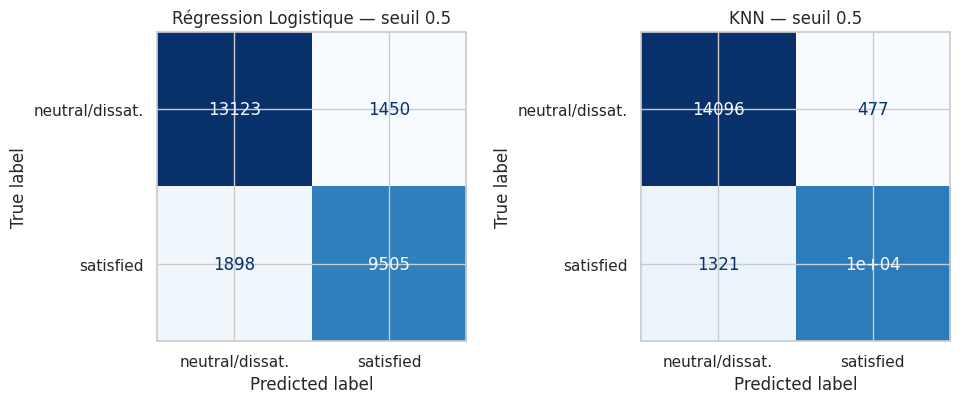

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, (name, model) in zip(axes, models.items()):
    pred = model.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['neutral/dissat.', 'satisfied']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name} — seuil 0.5")
plt.tight_layout()
plt.show()

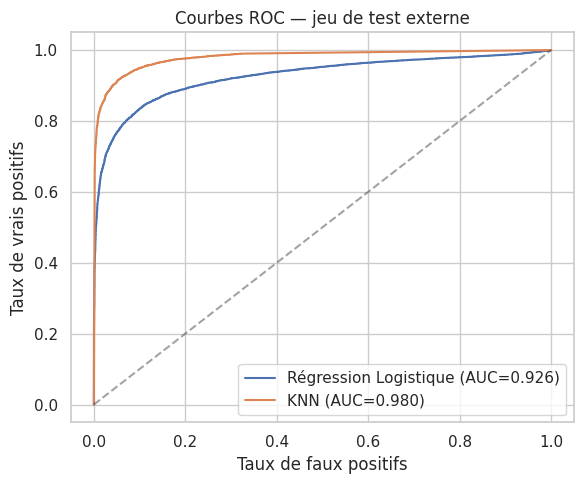

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, proba in proba_test.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.set_title("Courbes ROC — jeu de test externe")
ax.legend()
plt.tight_layout()
plt.show()

### Seuil de décision optimal

Le seuil par défaut (0.5) n'est pas nécessairement optimal pour notre métrique prioritaire. On balaie l'ensemble des seuils possibles et on retient celui qui maximise le F1-score macro (compromis recall/précision sur les deux classes), en comparant au recall obtenu à 0.5.

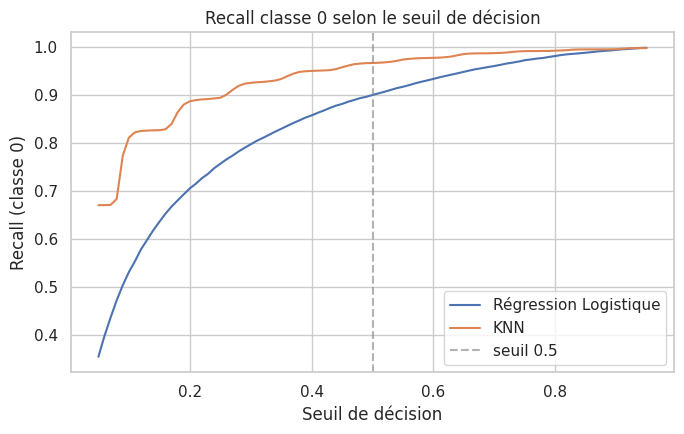

,Seuil optimal (F1 macro),Recall classe 0 @ 0.5,Recall classe 0 @ seuil optimal,F1 macro @ seuil optimal
Modèle,,,,
Régression Logistique,0.58,0.901,0.928,0.869
KNN,0.38,0.967,0.949,0.932


In [ ]:
def best_threshold(y_true, proba):
    thresholds = np.arange(0.05, 0.96, 0.01)
    scores = [f1_score(y_true, (proba >= t).astype(int), average='macro') for t in thresholds]
    best_t = thresholds[np.argmax(scores)]
    return best_t, max(scores)

fig, ax = plt.subplots(figsize=(7, 4.5))
threshold_rows = []
for name, proba in proba_test.items():
    thresholds = np.arange(0.05, 0.96, 0.01)
    recalls0 = [recall_score(y_test, (proba >= t).astype(int), pos_label=0) for t in thresholds]
    ax.plot(thresholds, recalls0, label=name)

    best_t, best_f1 = best_threshold(y_test, proba)
    pred_05 = (proba >= 0.5).astype(int)
    pred_opt = (proba >= best_t).astype(int)
    threshold_rows.append({
        'Modèle': name,
        'Seuil optimal (F1 macro)': round(best_t, 2),
        'Recall classe 0 @ 0.5': round(recall_score(y_test, pred_05, pos_label=0), 3),
        'Recall classe 0 @ seuil optimal': round(recall_score(y_test, pred_opt, pos_label=0), 3),
        'F1 macro @ seuil optimal': round(best_f1, 3)
    })

ax.axvline(0.5, color='gray', linestyle='--', alpha=0.6, label='seuil 0.5')
ax.set_xlabel("Seuil de décision")
ax.set_ylabel("Recall (classe 0)")
ax.set_title("Recall classe 0 selon le seuil de décision")
ax.legend()
plt.tight_layout()
plt.show()

pd.DataFrame(threshold_rows).set_index('Modèle')

Ajuster le seuil de décision permet de gagner plusieurs points de recall sur la classe prioritaire sans réentraîner le modèle, en acceptant en contrepartie une baisse de précision (plus de fausses alertes). Ce compromis est piloté par le seuil et peut être ajusté par la compagnie selon sa capacité opérationnelle à traiter les alertes (ex : si l'équipe relation-client ne peut traiter qu'un volume limité d'alertes par jour, on remontera le seuil pour privilégier la précision).

### Conclusion de l'évaluation

Sur le jeu de test externe et au seuil 0.5, le **KNN domine nettement** la régression logistique sur toutes les métriques : recall classe 0 de 96.7% contre 90.0%, ROC AUC de 0.980 contre 0.926, accuracy de 93.1% contre 87.1%. L'écart est cohérent avec l'EDA : les effets de seuil identifiés (âge non-linéaire, interactions de profil) sont capturés nativement par un modèle de voisinage, alors que la régression logistique doit s'appuyer sur des variables construites (`age_group`, `loyal_business`) pour s'en approcher, sans jamais totalement égaler un modèle non-linéaire par nature.

**Modèle retenu pour la prédiction : le KNN** (n_neighbors=11, weights='distance'). La régression logistique reste néanmoins conservée dans le livrable comme **modèle de référence interprétable** (section 9), un rôle que ses performances plus modestes ne remettent pas en cause : rapidité d'entraînement/inférence et lecture directe des coefficients en font un outil complémentaire précieux pour justifier les choix analytiques auprès de la compagnie.

## **9. Interprétation des modèles**

### 9.1 Coefficients de la régression logistique

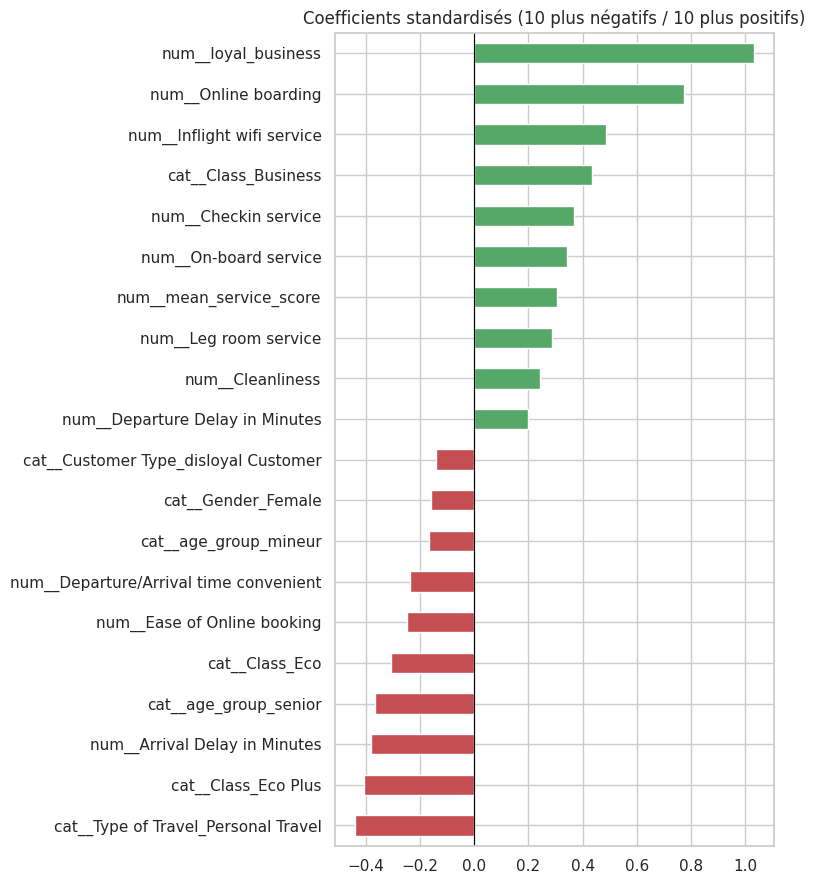

In [ ]:
feature_names = preprocess.get_feature_names_out()
coefs = pd.Series(lr_final.named_steps['clf'].coef_[0], index=feature_names).sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
top = pd.concat([coefs.head(10), coefs.tail(10)])
colors = top.apply(lambda x: '#C44E52' if x < 0 else '#55A868')
top.plot(kind='barh', ax=ax, color=colors)
ax.set_title("Coefficients standardisés (10 plus négatifs / 10 plus positifs)")
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Les deux coefficients positifs les plus élevés sont `num__loyal_business` (+1.03) et `num__Online boarding` (+0.77), suivis de `num__Inflight wifi service` (+0.48) et `cat__Class_Business` (+0.44) : ils confirment très directement les constats de l'EDA (section 5.1, 5.2 et 6). Côté négatif, `cat__Type of Travel_Personal Travel` (-0.44), `cat__Class_Eco Plus` (-0.41), `num__Arrival Delay in Minutes` (-0.38) et `cat__age_group_senior` (-0.36) ressortent le plus.

Deux résultats méritent d'être creusés :
- **`Arrival Delay in Minutes` ressort bien plus négativement en multivarié (-0.38) qu'en corrélation simple (-0.06, section 5.2).** Une fois les autres variables contrôlées (profil de voyage, qualité de service), l'effet propre du retard redevient visible — il était auparavant masqué par le fait que les voyageurs d'affaires satisfaits (peu sensibles aux notes de service) subissent aussi statistiquement plus de retards (vols plus fréquents, correspondances). C'est un bon rappel que corrélation univariée et coefficient multivarié répondent à deux questions différentes.
- **`Class_Eco Plus` est plus pénalisée (-0.41) que `Class_Eco` (non présent dans le top 10 mais négatif) une fois le profil de voyage contrôlé**, alors que son taux de satisfaction brut était supérieur (24.6% vs 18.6%, section 5.1). Hypothèse : les passagers Eco Plus, ayant payé un supplément, ont une attente plus élevée que les passagers Eco — un écart entre service perçu et service attendu, non observable directement dans les données mais cohérent avec ce résultat.

**Prudence de lecture** (cf. multicolinéarité, section 5.4) : les coefficients bruts des 14 notes de service individuelles peuvent apparaître modestes alors que le service global est très déterminant, simplement parce que l'information est partagée entre variables corrélées. C'est précisément pour cette raison qu'on a construit `mean_service_score` (+0.31, coefficient positif mais pas dans le top 4), dont l'apport est moins dans son amplitude individuelle que dans la stabilité et la lisibilité qu'il offre par rapport à 14 coefficients bruts corrélés entre eux.

### 9.2 Le cas du KNN : un modèle performant mais peu interprétable

Le KNN ne fournit ni coefficients ni notion de "feature importance" native : sa prédiction résulte d'un vote de voisinage dans l'espace des variables, sans relation explicite et globale entre une variable et la cible. C'est une **limite réelle** pour un livrable business qui doit "justifier les choix analytiques" — un décideur ne peut pas lire "telle variable augmente la satisfaction de X points" dans un KNN comme il peut le faire avec les coefficients de la régression logistique.

En pratique, on utilise donc la régression logistique comme **modèle d'interprétation** (quelles variables expliquent la satisfaction, pour la partie business du rapport) et on conserve le meilleur des deux modèles en **performance pure** (section 8) pour la partie prédictive. Les deux lectures des variables les plus discriminantes (LR d'un côté, écarts de moyennes de l'EDA de l'autre) convergent sur les mêmes facteurs (`loyal_business`, `Class`, `Type of Travel`, `Online boarding`), ce qui renforce la confiance dans ces résultats — un signal cohérent obtenu par deux approches indépendantes est plus robuste qu'un signal isolé.

## **10. Limites & biais**

**Biais de déclaration ("halo effect")**
Les 14 notes de service sont auto-déclarées par le passager. Un client globalement mécontent (ou content) a tendance à noter l'ensemble des services dans le même sens, indépendamment de la qualité réelle de chaque service pris isolément — c'est ce qui explique en grande partie la forte corrélation entre notes (section 5.4). Le modèle apprend donc en partie un "sentiment général" plutôt que 14 évaluations indépendantes.

**Ambiguïté des notes à 0**
Une note à 0 peut signifier "service non applicable/non utilisé" ou "très mauvais service" — le dataset ne permet pas de distinguer les deux cas. On a choisi de les garder telles quelles (section 3), un choix raisonnable mais qui n'élimine pas cette ambiguïté résiduelle.

**Corrélation, pas causalité**
Les variables `Customer Type`, `Type of Travel` et `Class` sont de forts prédicteurs mais reflètent un **profil global de voyage**, pas un levier d'action isolé. Rendre un client "loyal" n'améliorerait pas mécaniquement sa satisfaction ; c'est l'ensemble de l'expérience associée (priorité, confort, habitude) qui la explique. Toute recommandation opérationnelle doit cibler les leviers activables (qualité de service, expérience digitale) plutôt que les variables de profil elles-mêmes.

**Profil des répondants mineurs**
7.6% des passagers ont moins de 18 ans. Il est probable qu'un certain nombre de mineurs n'aient pas eux-mêmes rempli le questionnaire (réponse d'un accompagnant), ce qui ajoute du bruit non quantifiable à ces lignes.

**Généralisation**
Le dataset ne précise ni la compagnie, ni la zone géographique, ni la période de collecte. Les résultats (notamment les seuils de recall/précision) ne sont valables que pour une population de passagers structurellement proche de celle-ci ; ils devront être ré-évalués si la compagnie change de marché ou de segmentation de clientèle.

**Limite opérationnelle du KNN**
Le KNN est un algorithme "paresseux" : il ne s'entraîne pas à proprement parler, il stocke l'intégralité du jeu d'entraînement et calcule une distance à chaque prédiction. Sur des volumes bien plus importants que ce dataset (plusieurs millions de passagers), le temps d'inférence et le stockage mémoire deviendraient un frein réel en production, contrairement à la régression logistique dont l'inférence est quasi instantanée (produit matriciel léger).

## **11. Choix méthodologiques**

Récapitulatif des décisions structurantes prises au cours du projet, et pourquoi on a retenu chacune plutôt qu'une alternative.

### 11.1 Un jeu de test externe plutôt qu'un split artificiel

La compagnie fournit `train.csv` et `test.csv` séparément, avec des distributions de cible quasi identiques (section 2). Plutôt que de re-fusionner les deux fichiers pour faire un split maison, on a conservé cette séparation et ajouté un split interne (train/validation) uniquement pour le tuning. Le jeu `test.csv` n'est utilisé qu'une seule fois, à la toute fin (section 8) — c'est la meilleure garantie contre le sur-ajustement aux données de test.

### 11.2 Traitement des valeurs manquantes

Une seule variable est concernée (`Arrival Delay in Minutes`, 0.3% de lignes). Plutôt qu'une imputation générique par la médiane, on a vérifié que ces lignes avaient des retards au départ plausibles (section 3) puis utilisé cette variable très corrélée (r=0.96) comme proxy d'imputation — plus fidèle à la réalité qu'une constante globale.

### 11.3 Stratégie de feature engineering

Les trois variables créées (`loyal_business`, `mean_service_score`, `age_group`) découlent chacune d'un constat précis de l'EDA (section 5) et ont été validées par leur corrélation à la cible avant d'être retenues (section 6). On n'a pas cherché à multiplier les variables construites au-delà de ce que l'analyse justifiait.

### 11.4 Gestion du déséquilibre des classes

On a testé empiriquement `class_weight=None` vs `'balanced'` sur la régression logistique (section 7.3) plutôt que d'appliquer une règle par défaut. Le déséquilibre (43/57) étant mineur et la classe prioritaire déjà majoritaire, le rééquilibrage automatique s'est révélé contre-productif pour notre métrique métier. On a préféré agir sur le **seuil de décision** (section 8), un levier plus ciblé et réversible sans réentraînement.

### 11.5 Choix des modèles et de la métrique d'évaluation

Le cahier des charges imposait une méthode de régression ou de KNN : on a choisi de développer **les deux** pour pouvoir les comparer. La régression logistique sert de modèle de référence interprétable (coefficients directement lisibles, utile pour "justifier les choix analytiques" demandé dans le livrable) ; le KNN capture les effets de seuil non-linéaires identifiés en EDA (âge notamment) sans transformation préalable. La métrique prioritaire (recall classe `neutral or dissatisfied`) découle directement de l'objectif métier (section 4), suivie du F1 macro et du ROC AUC pour garder une vision équilibrée.

### 11.6 Stratégie de tuning des hyperparamètres

`GridSearchCV` (5 folds) a été préféré à `RandomizedSearchCV` car les deux grilles de recherche (5 valeurs de `C` pour la LR, 5 valeurs de `k` × 2 stratégies de pondération pour le KNN) restent petites et rapides à explorer exhaustivement sur ce volume de données (~83 000 lignes d'entraînement) — inutile d'échantillonner aléatoirement l'espace des hyperparamètres quand on peut le couvrir entièrement en quelques dizaines de secondes.

### 11.7 Granularité des variables : pourquoi garder le détail plutôt que le résumer

**Les 3 variables faiblement corrélées (`Gate location`, `Departure/Arrival time convenient`, `Arrival Delay in Minutes`)**

Ces trois variables ressortaient de l'EDA comme quasi non-informatives ou redondantes (section 5.2 et 5.4). Plutôt que de les retirer par principe, on a testé empiriquement leur suppression sur le KNN (section 7.5), le modèle le plus exposé à ce type de variable du fait de son calcul de distance sur toutes les dimensions à poids égal. Le résultat n'a montré aucune différence significative de performance (écarts de l'ordre de 0.0001 à 0.0006 sur le recall, le F1 macro et le ROC AUC). On les a donc conservées : les retirer n'aurait été qu'une simplification cosmétique sans gain mesurable, alors que les garder assure une comparaison équitable entre la régression logistique et le KNN (mêmes variables en entrée pour les deux modèles) et permet aux coefficients de la régression logistique (section 9.1) de confirmer explicitement, de façon transparente, leur faible poids réel.

**Les 14 notes de service individuelles plutôt qu'une seule moyenne**

Pour la même raison de fond, on a choisi de garder les 14 variables de notation de service (`Online boarding`, `Seat comfort`, `Inflight entertainment`...) en plus de `mean_service_score`, plutôt que de résumer les 14 en une seule moyenne. Une moyenne fait perdre une information essentielle : deux passagers peuvent avoir exactement le même score moyen tout en ayant des profils très différents (l'un insatisfait uniquement du wifi, l'autre uniformément moyen partout), et surtout les 14 services n'ont pas du tout le même pouvoir prédictif (`Online boarding` à 0.50 de corrélation avec la cible contre `Gate location` à 0.001) — une moyenne dilue les signaux forts avec le bruit des signaux faibles.

Mais l'argument le plus important est **opérationnel, pas seulement statistique** : garder le détail des 14 services est ce qui permet, en section 9 et en conclusion, d'identifier précisément **quel service améliorer en priorité** (`Online boarding`, `Inflight entertainment`...) plutôt que de se limiter au constat vague "la qualité de service compte". Une compagnie aérienne qui voudrait agir sur cette analyse a besoin de savoir *où* investir concrètement (l'embarquement en ligne, le divertissement à bord) — une information que `mean_service_score` seule ne peut pas donner, puisqu'elle agrège tout en un seul chiffre. `mean_service_score` garde son utilité propre (une lecture agrégée et stable pour l'interprétation globale, section 6), mais elle vient en complément des 14 variables détaillées, pas à leur place.

## **12. Conclusion**

Ce projet répondait à quatre objectifs fixés par la mission (section "Votre rôle" du brief) :

**Analyser les données recueillies**
L'EDA a permis de dégager un profil clair du passager satisfait : voyageur d'affaires, en classe Business, client fidèle, âgé de 45 à 60 ans; et à l'inverse un profil à risque : voyageur personnel en classe Eco, jeune ou senior.

**Identifier des motifs**
Trois constats structurants ressortent : la synergie "business + fidèle" (variable `loyal_business`, corrélation 0.56), la prédominance de la qualité de service perçue sur la ponctualité (corrélations 0.3-0.5 contre -0.05/-0.06 pour les retards), et l'effet non-linéaire de l'âge (courbe en cloche culminant à 45-60 ans).

**Interroger corrélation et causalité**
On a explicitement distingué les variables de profil (fortement corrélées mais non actionnables directement) des variables de service (corrélées et actionnables) — une nuance essentielle pour transformer ces résultats en recommandations opérationnelles plutôt qu'en simples constats statistiques.

**Prédire le niveau de satisfaction**
Les deux modèles (régression logistique et KNN) atteignent des performances solides sur le jeu de test externe (détail chiffré section 8), avec un arbitrage clair entre interprétabilité (régression logistique) et performance pure sur les non-linéarités (KNN).

**Recommandations pour la compagnie :**
- Prioriser les investissements sur l'expérience digitale d'embarquement (`Online boarding`, l'écart le plus discriminant du dataset) et le divertissement à bord, plutôt que sur la seule réduction des retards.
- Utiliser le score de risque prédictif (probabilité de dissatisfaction) pour cibler en priorité les voyageurs personnels en classe Eco, jeunes ou seniors — les profils les plus à risque identifiés.
- Surveiller le seuil de décision du modèle en production et l'ajuster selon la capacité opérationnelle de l'équipe relation-client à traiter les alertes générées.